### This script takes mitgcm harmonic analysis outputs as well as tpxo product interpolated on llc1080 grid. 

In [1]:
import numpy as np
import xarray as xr
from xmitgcm import open_mdsdataset
import matplotlib.pyplot as plt
import ecco_v4_py as ecco

import matplotlib
matplotlib.colormaps.get_cmap("cool")
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['font.size'] = 13

#from ecco_v4_py import plot_proj_to_latlon_grid
import time
import warnings
from cmcrameri import cm
warnings.filterwarnings(
    "ignore", 
    category=FutureWarning, 
    message=".*decode_timedelta will default to False.*"
)


### Import grid files

In [3]:
"""
I need XC,YC rA and hfacC. The simplest way I found was to import 1point of time series, and extract the grid from there. 
The Eta point is from the first run of Dan with hourly output, but it doesn't matter anyway, since I only need the grid.
It's very quick, but the inconvenient is that I need to store the grid folder 'run_dan' locally.
There is surely a smarter way.
"""
ds_eta1 = open_mdsdataset('../../Eta_1point', 
                        grid_dir='../../run_dan', 
                         prefix={'Eta'},
                         read_grid=True,
                         geometry="llc")
ds_eta1 = ds_eta1.rename({'face':'tile'})
XC = ds_eta1['XC'].data
YC = ds_eta1['YC'].data

# Create a landmask by checking if the sum of hfacC over all the layers of the column in 0. But considering all layers and not only the first one, we keep water points covered by sea ice.
hfac_tile =ds_eta1.coords['hFacC'].sum(dim='k').values 
is_ocean = hfac_tile > 0
rA = ds_eta1['rA']
bath = ds_eta1['Depth']

rA = rA.where(is_ocean)
bath=bath.where(is_ocean)

/Users/hugopp/miniconda3/envs/mitgcmenv_clean/lib/python3.11/site-packages/xmitgcm/mds_store.py:913: UserWarning: Couldn't find available_diagnostics.log in ../../Eta_1point or ../../run_dan. Using default version.
  warnings.warn("Couldn't find available_diagnostics.log "
/Users/hugopp/miniconda3/envs/mitgcmenv_clean/lib/python3.11/site-packages/xmitgcm/mds_store.py:289: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds['time'] = xr.decode_cf(ds[['time']])['time']


In [4]:
def open_mitgcm_and_make_da(mitgcm_path,ntiles = 13,ncells=1080):
    ds_mitgcm = xr.open_mfdataset(mitgcm_path, concat_dim='tile', combine='nested')
    ### Creating Data array from dataset
    da_phasor= xr.DataArray(
        ds_mitgcm.amp.data,  # This is misscalled amp but is actually phasor.
        dims=["tile", "constituent", "i", "j"], # Match the actual order: 13, 15, 1080, 1080
        coords={
            "tile": np.arange(ntiles),
            "constituent": ds_mitgcm.constituent, 
            "i": np.arange(ncells),
            "j": np.arange(ncells),
            "XC": (["tile", "i", "j"], XC),
            "YC": (["tile", "i", "j"], YC),
           # 'RAC':(["tile", "i", "j"], RAC)
            },
        name="phasor"
    )
    da_phasor=(da_phasor.rename({"i": "j", "j": "i"}))#Invert the axis to agree with MITgcm
    return da_phasor
def order_tiles(da, new_tile_order):
    ''' Reorder tiles if they are in the wrong order'''
    da_ordered = da.isel(tile=new_tile_order)
    # Overwrite the 'tile' coordinate so it is a clean 0-12 sequence
    da_ordered.coords['tile'] = np.arange(len(new_tile_order))
    return da_ordered

### Open TPXO Interpolated to LLC1080

In [5]:
def open_tpxo(tpxo_path):
    """
    Open tpxo tidal map interpolated to llc1080. This map is computed in the notebook 'XXX'
    """
    ds_tpxo_llc = xr.open_mfdataset(tpxo_path)
    #ds_tpxo_llc=(ds_tpxo_llc.rename({"i": "j", "j": "i"}))#Invert the axis to agree with MITgcm
    return ds_tpxo_llc

# Phasor, amplitude and phase maps extraction

In [110]:
def mitgcm_quantities(da_mitgcm,constit= 'm2',lat_cut=False,lat_deg=66):
    '''
    Return given tidal constituent phasor, amplitude and phase for MITgcm
    Amplitude given in meters, phase in radian
    '''
    da_mitgcm_constit = da_mitgcm.sel(constituent=constit)
    
    Z_mitgcm =  da_mitgcm_constit.data['r'] + 1j*da_mitgcm_constit.data['i'] #Build Phasor
    da_Z_mitgcm = xr.DataArray(Z_mitgcm, coords=da_mitgcm_constit.coords, dims=da_mitgcm_constit.dims)
    Z_mitgcm_masked = da_Z_mitgcm.where(is_ocean) #Apply landmask to 
    if lat_cut ==True: #Optional latitude cut to remove the poles
        Z_mitgcm_masked = Z_mitgcm_masked.where((YC >= -lat_deg) &(YC <= lat_deg)) 
    amp_mitgcm= np.abs(Z_mitgcm_masked) #Tidal amplitude
    phase_mitgcm = -xr.apply_ufunc(np.angle, Z_mitgcm_masked,dask='allowed')  #I use a - sign convention on the phase, necessary to obtain the right value of global tidal work rate.
    return Z_mitgcm_masked,amp_mitgcm, phase_mitgcm
    
def tpxo_quantities(da_tpxo, constit='m2',lat_cut=False,lat_deg=66):
    '''
    Return given tidal constituent phasor, amplitude and phase for TPXO
    Amplitude given in meters, phase in radian
    '''

    Z_tpxo = da_tpxo[constit+'_real'] + 1j*da_tpxo[constit+'_imag']
    if lat_cut ==True: #Optional latitude cut to remove the poles
        Z_tpxo = Z_tpxo.where((YC >= -lat_deg) &(YC <= lat_deg)) 
    Z_tpxo_masked = Z_tpxo.where(is_ocean)
    amp_tpxo= np.abs(Z_tpxo_masked)

    phase_tpxo=-xr.apply_ufunc(np.angle, Z_tpxo_masked,dask='allowed') #I use a - sign convention on the phase, necessary to obtain the right value of global tidal work rate.
    return Z_tpxo_masked, amp_tpxo,phase_tpxo
def phase_diff (phase1,phase2):
    '''
    Return the wrapped difference between two phase maps of a given tidal constituent
    '''
    return np.angle(np.exp(1j * (phase1 - phase2)))

def correct_phasediff_by_mean_offset(Z1,Z2):
    '''
    Function written for the case where I find a global offset between two phase maps. 
    It substracts the mean phase difference to the phasor Z2, before computing a new phase difference.
    '''
    dZ_ph1_ph2 = Z1 *np.conj(Z_2)
    mean_offset =  np.angle(dZ_phi1_ph2.stack(space=("tile","j","i")).mean(dim="space"))
    Z2_shifted = Z2* np.exp(1j * mean_offset)
    phase1 = np.angle(Z1)
    phase2_shifted = np.angle(Z2_shifted)
    phase_diff_shifted =  np.angle(np.exp(1j * (phase1 - phase2_shifted)))
    return phase_diff_shifted
    
def phase_rad2deg(phase,da_phasor):
    return xr.DataArray(np.rad2deg(phase), coords=da_phasor.coords, dims=da_phasor.dims)

def field_deep_shallow(field, bathimetry, limit_depth=1000,lat_cut=False, lat_deg =66):
    '''
    Return subpart of the field, whith depth superior and inferior to the indicated limit (in meters)
    '''
    if lat_cut ==True: #Optional latitude cut to remove the poles
        field = field.where((YC >= -lat_deg) &(YC <= lat_deg)) 
    field_deep = field.where(bathimetry > limit_depth)
    field_shallow = field.where((bathimetry > 0) & (bathimetry <= 1000))
    
        
    return field_deep,field_shallow
    

# RMSE and PVE computation

In [66]:
"""
Formulae taken from Opel et al. 2024 supplementary note, section 'Validation'
Link to the paper: https://www.nature.com/articles/s43247-024-01432-5#Sec20
Link to supplementary information: https://static-content.springer.com/esm/art%3A10.1038%2Fs43247-024-01432-5/MediaObjects/43247_2024_1432_MOESM2_ESM.pdf
"""
def RMS(X,rAX):
    return 1e2*np.sqrt(np.nansum(X**2*rAX)/(2*np.nansum(rAX)))
def RMSE(X1,X2,rAX):
    return 1e2*np.sqrt(np.nansum((X1-X2)**2*rAX)/(2*np.nansum(rAX)))
def RMSZ(Z,rAX):
    return 1e2*np.sqrt(np.nansum(np.abs(Z)**2*rAX)/(2*np.nansum(rAX)))
def RMSEZ(Z1,Z2,rAX):
    return 1e2*np.sqrt(np.nansum(np.abs(Z1-Z2)**2*rAX)/(2*np.nansum(rAX)))
def PVE(RMSE_1_2, RMS_2):
    ''' 
    Compute percentage of variance explained between two fields 1 and 2 (directly in %, which is why there is a *1e2)
    RMS_2 is the RMS of the field to which we compare to. In our case, TPXO amplitude.
    '''
    return 1e2*(1-(RMSE_1_2/RMS_2)**2)

# Tidal work rate

In [120]:
def tidal_workrate(ampli,phase,lon_rad,lat_rad,constit):
    '''
    Computes tidal work rate as a map (Pmap), and integrated over the Earth (Ptot). 
    Pmap is in mW/m^2, Ptot in TW.
    The computation is available for the 8 major constituents only.
    A demonstration of the formula can be found at: https://www.overleaf.com/read/qjvkkmnvjvkw#689c95
     Values of omega, A_eq and love_number_factor are taken from Arbic et al. 2004 Table 1
    '''
    if constit.lower() not in ['m2','s2','n2','k2','k1','o1','q1','p1']:
        raise ValueError(f"Tidal workrate computation is not available for constituent '{constit}'")
    # rho_0: Mean density of seawater (kg/m^3)
    rho_0 = 1025.0
    # g: Acceleration due to gravity (m/s^2)
    g = 9.81 
    # R_E: Mean radius of the Earth (m)
    R_E = 6_371_000.0   

    # omega: Angular frequency of the tidal constituent (rad/s).
    # omega = 2 * pi / (frequency [in hours] * 3600 seconds)
    omega_list = {
    "m2": 1.405189e-4,
    "s2": 1.455551e-4,
    "n2": 1.378797e-4,
    "k2": 1.458423e-4,
    "k1": 0.7292117e-4,
    "o1": 0.6759774e-4,
    "p1": 0.7252295e-4,
    "q1": 0.6495854e-4,
}
    omega=omega_list[constit]
    # A_eq: Amplitude of the equilibrium tide potential on a rigid Earth (m). 
    equilibrium_amp_list = {
    "m2": 0.242334,
    "s2": 0.112743,
    "n2": 0.046397,
    "k2": 0.030684,
    "k1": 0.141565,
    "o1": 0.100661,
    "p1": 0.046848,
    "q1": 0.019273,
}
    A_eq = equilibrium_amp_list[constit]

    # love_number_factor: (1 + k_2 - h_2).
    # This factor accounts for the solid Earth's elastic response.
    love_number_factor_list = {
    "m2": 0.693,
    "s2": 0.693,
    "n2": 0.693,
    "k2": 0.693,
    "k1": 0.736,
    "o1": 0.695,
    "p1": 0.706,
    "q1": 0.695,
    }
    love_number_factor = love_number_factor_list[constit]
    constant_prefix = - (rho_0 * g / 2.0) * A_eq * love_number_factor * omega #kg.m^-1.s^-3
    #print('constant prefix', constant_prefix,'kg m^-1 s^-3')

    if constit in ['m2','s2','n2','k2']: #Semi-diurnal constituent
        Pmap = 1e3*constant_prefix* ampli * np.cos(lat_rad)**2 *  np.sin(phase + 2*lon_rad) #mW/m^2
        Ptot = 1e-12*constant_prefix* (ampli * np.cos(lat_rad)**2 * np.sin(phase + 2*lon_rad)*rA*is_ocean).sum() #TW
        print('Total working rate for '+constit+' = ', Ptot.compute().item(),'TW')
    elif constit in ['k1','o1','q1','p1']: #Diurnal constituent
        Pmap = 1e3*constant_prefix* ampli * np.sin(2*lat_rad) *  np.sin(phase + lon_rad) #mW/m^2
        Ptot = 1e-12*constant_prefix* (ampli * np.sin(2*lat_rad) * np.sin(phase + lon_rad)*rA*is_ocean).sum() #TW
        print('Total working rate for '+constit+' = ', Ptot.compute().item(),'TW')
    return Ptot,Pmap

# Example of usage: noSAL, SAL and SAL40sh runs

In [67]:
da_phasor_noSAL = open_mitgcm_and_make_da(mitgcm_path='../../run_ATH_noSAL/mitgcm_llc1080_phasor_tile*.nc')
da_phasor_SAL= open_mitgcm_and_make_da(mitgcm_path='../../run_ATH_SAL/mitgcm_llc1080_phasor_tile*.nc')
da_phasor_SAL40sh = open_mitgcm_and_make_da(mitgcm_path='../../run_ATH_SAL_40SH/mitgcm_llc1080_phasor_tile*.nc')

da_phasor_noSAL = order_tiles(da_phasor_noSAL, new_tile_order=[0, 4, 5, 6, 7, 8, 9,10,11,12,1,2,3] )
da_phasor_SAL = order_tiles(da_phasor_SAL, new_tile_order=[0, 4, 5, 6, 7, 8, 9,10,11,12,1,2,3] )
da_phasor_SAL40sh = order_tiles(da_phasor_SAL40sh, new_tile_order=[0, 4, 5, 6, 7, 8, 9,10,11,12,1,2,3] )

In [77]:
print(da_phasor_noSAL)
print(da_phasor_SAL['constituent'].values)

<xarray.DataArray 'phasor' (tile: 13, constituent: 15, j: 1080, i: 1080)> Size: 4GB
dask.array<getitem, shape=(13, 15, 1080, 1080), dtype={'names': ['r', 'i'], 'formats': ['<f8', '<f8'], 'offsets': [0, 8], 'itemsize': 16, 'aligned': True}, chunksize=(1, 15, 1080, 1080), chunktype=numpy.ndarray>
Coordinates:
  * tile         (tile) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * constituent  (constituent) <U3 180B 'm2' 's2' 'n2' 'k2' ... 'ms4' '2n2' 's1'
  * j            (j) int64 9kB 0 1 2 3 4 5 6 ... 1074 1075 1076 1077 1078 1079
  * i            (i) int64 9kB 0 1 2 3 4 5 6 ... 1074 1075 1076 1077 1078 1079
    XC           (tile, j, i) >f4 61MB dask.array<chunksize=(1, 1080, 1080), meta=np.ndarray>
    YC           (tile, j, i) >f4 61MB dask.array<chunksize=(1, 1080, 1080), meta=np.ndarray>
['m2' 's2' 'n2' 'k2' 'k1' 'o1' 'p1' 'q1' 'mm' 'mf' 'm4' 'mn4' 'ms4' '2n2'
 's1']


In [69]:
ds_tpxo_llc = open_tpxo(tpxo_path ='../../tpxo_interpolated/tpxo_llc1080_interpolated_v2.nc')

In [136]:
const = 'p1' # Name of the constituent to analyze
cut_66 =False #Do we remove the poles? Set True if this is the case, False otherwise.
if cut_66==True:
    Z_mitgcm_noSAL, amp_mitgcm_noSAL, phase_mitgcm_noSAL = mitgcm_quantities(da_phasor_noSAL, constit = const,lat_cut=True,lat_deg=66)
    Z_mitgcm_SAL, amp_mitgcm_SAL, phase_mitgcm_SAL = mitgcm_quantities(da_phasor_SAL, constit = const,lat_cut=True,lat_deg=66)
    Z_mitgcm_SAL40sh, amp_mitgcm_SAL40sh, phase_mitgcm_SAL40sh = mitgcm_quantities(da_phasor_SAL40sh, constit = const,lat_cut=True,lat_deg=66)
    Z_tpxo, amp_tpxo, phase_tpxo= tpxo_quantities(ds_tpxo_llc, constit=const,lat_cut=True,lat_deg=66)
    rA=rA.where((YC >= -66) &(YC <=66)) 
else: 
    Z_mitgcm_noSAL, amp_mitgcm_noSAL, phase_mitgcm_noSAL = mitgcm_quantities(da_phasor_noSAL, constit = const)
    Z_mitgcm_SAL, amp_mitgcm_SAL, phase_mitgcm_SAL = mitgcm_quantities(da_phasor_SAL, constit = const)
    Z_mitgcm_SAL40sh, amp_mitgcm_SAL40sh, phase_mitgcm_SAL40sh = mitgcm_quantities(da_phasor_SAL40sh, constit =const)
    Z_tpxo, amp_tpxo, phase_tpxo= tpxo_quantities(ds_tpxo_llc, constit=const)
    
phase_diff_noSAL_tpxo=  phase_diff(phase_mitgcm_noSAL,phase_tpxo)
phase_diff_SAL_tpxo=  phase_diff(phase_mitgcm_SAL,phase_tpxo)
phase_diff_SAL40sh_tpxo=  phase_diff(phase_mitgcm_SAL40sh,phase_tpxo)

In [81]:
RMS_tpxo = RMS(amp_tpxo, rA)

RMSE_amp_noSAL_tpxo = RMSE(amp_mitgcm_noSAL,amp_tpxo,rA)
PVE_noSAL_tpxo = PVE(RMSE_amp_noSAL_tpxo, RMS_tpxo)

RMSE_amp_SAL_tpxo = RMSE(amp_mitgcm_SAL,amp_tpxo,rA)
PVE_SAL_tpxo = PVE(RMSE_amp_SAL_tpxo, RMS_tpxo)

RMSE_amp_SAL40sh_tpxo = RMSE(amp_mitgcm_SAL40sh,amp_tpxo,rA)
PVE_SAL40sh_tpxo = PVE(RMSE_amp_SAL40sh_tpxo, RMS_tpxo)
print('For the M2 constituent')
print(' ')
print('RMS tpxo amplitude ',RMS_tpxo,'cm')
print( ' ')
print('RMSE amplitude (MITGCM_noSAL-TPXO) =',RMSE_amp_noSAL_tpxo,'cm')
print('PVEamplitude (MITGCM_noSAL-TPXO)  =', PVE_noSAL_tpxo,'%')
print('RMSE amplitude (MITGCM_SAL-TPXO)  =',RMSE_amp_SAL_tpxo,'cm')
print('PVE amplitude (MITGCM_SAL-TPXO)  =', PVE_SAL_tpxo,'%')
print('RMSE amplitude (MITGCM_SAL40sh-TPXO)  =',RMSE_amp_SAL40sh_tpxo,'cm')
print('PVE amplitude (MITGCM_SAL40sh-TPXO)  =', PVE_SAL40sh_tpxo,'%')

# RMSE Phasor
print(' ')
RMSE_Z_noSAL_tpxo = RMSEZ(Z_mitgcm_noSAL,Z_tpxo,rA)
PVEZ_noSAL_tpxo = PVE(RMSE_Z_noSAL_tpxo, RMS_tpxo) 
RMSE_Z_SAL_tpxo = RMSEZ(Z_mitgcm_SAL,Z_tpxo,rA)
PVEZ_SAL_tpxo= PVE(RMSE_Z_SAL_tpxo, RMS_tpxo) 
RMSE_Z_SAL40sh_tpxo = RMSEZ(Z_mitgcm_SAL40sh,Z_tpxo,rA)
PVEZ_SAL40sh_tpxo= PVE(RMSE_Z_SAL40sh_tpxo, RMS_tpxo) 
print('RMSE phasor  (MITGCM_noSAL-TPXO) =', RMSE_Z_noSAL_tpxo, 'cm')
print('PVE phasor  (MITGCM_noSAL-TPXO) =', PVEZ_noSAL_tpxo,'%')
print('RMSE phasor  (MITGCM_SAL-TPXO) =', RMSE_Z_SAL_tpxo, 'cm')
print('PVE phasor  (MITGCM_SAL-TPXO) =', PVEZ_SAL_tpxo,'%')
print('RMSE phasor  (MITGCM_SAL40sh-TPXO) =', RMSE_Z_SAL40sh_tpxo, 'cm')
print('PVE phasor  (MITGCM_SAL40sh-TPXO) =', PVEZ_SAL40sh_tpxo,'%')
print(' ')


For the M2 constituent
 
RMS tpxo amplitude  29.065237 cm
 
RMSE amplitude (MITGCM_noSAL-TPXO) = 12.62531098364873 cm
PVEamplitude (MITGCM_noSAL-TPXO)  = 81.13154109847802 %
RMSE amplitude (MITGCM_SAL-TPXO)  = 7.430239702897729 cm
PVE amplitude (MITGCM_SAL-TPXO)  = 93.46481463414328 %
RMSE amplitude (MITGCM_SAL40sh-TPXO)  = 7.274711173995398 cm
PVE amplitude (MITGCM_SAL40sh-TPXO)  = 93.73553810148478 %
 
RMSE phasor  (MITGCM_noSAL-TPXO) = 25.980375136897944 cm
PVE phasor  (MITGCM_noSAL-TPXO) = 20.100677488382335 %
RMSE phasor  (MITGCM_SAL-TPXO) = 10.51360857420963 cm
PVE phasor  (MITGCM_SAL-TPXO) = 86.91553802101211 %
RMSE phasor  (MITGCM_SAL40sh-TPXO) = 10.111532365039407 cm
PVE phasor  (MITGCM_SAL40sh-TPXO) = 87.89719003764735 %
 


### Deep and Shallow RMS

In [101]:
print('Cut 66deg?', cut_66) #Just to remind us if the poles cut is activated
if cut_66==True:
    Z_mitgcm_noSAL_deep,Z_mitgcm_noSAL_shal = field_deep_shallow(Z_mitgcm_noSAL, bath, limit_depth=1000,lat_cut=True,lat_deg=66)
    amp_mitgcm_noSAL_deep,amp_mitgcm_noSAL_shal = field_deep_shallow(amp_mitgcm_noSAL, bath, limit_depth=1000,lat_cut=True,lat_deg=66)
    
    Z_mitgcm_SAL_deep,Z_mitgcm_SAL_shal = field_deep_shallow(Z_mitgcm_SAL, bath, limit_depth=1000,lat_cut=True,lat_deg=66)
    amp_mitgcm_SAL_deep,amp_mitgcm_SAL_shal = field_deep_shallow(amp_mitgcm_SAL, bath, limit_depth=1000,lat_cut=True,lat_deg=66)
    
    Z_mitgcm_SAL40sh_deep,Z_mitgcm_SAL40sh_shal = field_deep_shallow(Z_mitgcm_SAL40sh, bath, limit_depth=1000,lat_cut=True,lat_deg=66)
    amp_mitgcm_SAL40sh_deep,amp_mitgcm_SAL40sh_shal = field_deep_shallow(amp_mitgcm_SAL40sh, bath, limit_depth=1000,lat_cut=True,lat_deg=66)
    
    Z_tpxo_deep,Z_tpxo_shal = field_deep_shallow(Z_tpxo, bath, limit_depth=1000,lat_cut=True,lat_deg=66)
    amp_tpxo_deep,amp_tpxo_shal = field_deep_shallow(amp_tpxo, bath, limit_depth=1000,lat_cut=True,lat_deg=66)

    rA_deep, rA_shal= field_deep_shallow(rA, bath, limit_depth=1000,lat_cut=True,lat_deg=66)
else:
    Z_mitgcm_noSAL_deep,Z_mitgcm_noSAL_shal = field_deep_shallow(Z_mitgcm_noSAL, bath, limit_depth=1000)
    amp_mitgcm_noSAL_deep,amp_mitgcm_noSAL_shal = field_deep_shallow(amp_mitgcm_noSAL, bath, limit_depth=1000)
    
    Z_mitgcm_SAL_deep,Z_mitgcm_SAL_shal = field_deep_shallow(Z_mitgcm_SAL, bath, limit_depth=1000)
    amp_mitgcm_SAL_deep,amp_mitgcm_SAL_shal = field_deep_shallow(amp_mitgcm_SAL, bath, limit_depth=1000)
    
    Z_mitgcm_SAL40sh_deep,Z_mitgcm_SAL40sh_shal = field_deep_shallow(Z_mitgcm_SAL40sh, bath, limit_depth=1000)
    amp_mitgcm_SAL40sh_deep,amp_mitgcm_SAL40sh_shal = field_deep_shallow(amp_mitgcm_SAL40sh, bath, limit_depth=1000)
    
    Z_tpxo_deep,Z_tpxo_shal = field_deep_shallow(Z_tpxo, bath, limit_depth=1000)
    amp_tpxo_deep,amp_tpxo_shal = field_deep_shallow(amp_tpxo, bath, limit_depth=1000)

    rA_deep, rA_shal= field_deep_shallow(rA, bath, limit_depth=1000)

Cut 66deg? False


In [119]:
RMS_tpxo_deep = RMS(amp_tpxo_deep, rA_deep)
RMS_tpxo_shal = RMS(amp_tpxo_shal, rA_shal)

RMSE_amp_noSAL_tpxo_deep = RMSE(amp_mitgcm_noSAL_deep,amp_tpxo_deep,rA_deep)
PVE_noSAL_tpxo_deep = PVE(RMSE_amp_noSAL_tpxo_deep, RMS_tpxo_deep)
RMSE_amp_noSAL_tpxo_shal= RMSE(amp_mitgcm_noSAL_shal,amp_tpxo_shal,rA_shal)
PVE_noSAL_tpxo_shal= PVE(RMSE_amp_noSAL_tpxo_shal, RMS_tpxo_shal)

RMSE_amp_SAL_tpxo_deep = RMSE(amp_mitgcm_SAL_deep,amp_tpxo_deep,rA_deep)
PVE_SAL_tpxo_deep = PVE(RMSE_amp_SAL_tpxo_deep, RMS_tpxo_deep)
RMSE_amp_SAL_tpxo_shal = RMSE(amp_mitgcm_SAL_shal,amp_tpxo_shal,rA_shal)
PVE_SAL_tpxo_shal = PVE(RMSE_amp_SAL_tpxo_shal, RMS_tpxo_shal)

RMSE_amp_SAL40sh_tpxo_deep = RMSE(amp_mitgcm_SAL40sh_deep,amp_tpxo_deep,rA_deep)
PVE_SAL40sh_tpxo_deep = PVE(RMSE_amp_SAL40sh_tpxo_deep, RMS_tpxo_deep)
RMSE_amp_SAL40sh_tpxo_shal = RMSE(amp_mitgcm_SAL40sh_shal,amp_tpxo_shal,rA_shal)
PVE_SAL40sh_tpxo_shal = PVE(RMSE_amp_SAL40sh_tpxo_shal, RMS_tpxo_shal)
print('For the M2 constituent')
print(' ')
print('DEEP')
print('RMS tpxo amplitude',RMS_tpxo_deep,'cm')
print(' ')
print('SHALLOW')
print('RMS tpxo amplitude',RMS_tpxo_shal,'cm')
print( ' ')
print('DEEP')
print('RMSE amplitude (MITGCM_noSAL-TPXO)=',RMSE_amp_noSAL_tpxo_deep,'cm')
print('PVEamplitude (MITGCM_noSAL-TPXO)  =', PVE_noSAL_tpxo_deep,'%')
print('RMSE amplitude (MITGCM_SAL-TPXO) =',RMSE_amp_SAL_tpxo_deep,'cm')
print('PVE amplitude (MITGCM_SAL-TPXO)  =', PVE_SAL_tpxo_deep,'%')
print('RMSE amplitude (MITGCM_SAL40sh-TPXO)  =',RMSE_amp_SAL40sh_tpxo_deep,'cm')
print('PVE amplitude (MITGCM_SAL40sh-TPXO) =', PVE_SAL40sh_tpxo_deep,'%')
print( ' ')
print('SHALLOW')
print('RMSE amplitude (MITGCM_noSAL-TPXO) =',RMSE_amp_noSAL_tpxo_shal,'cm')
print('PVEamplitude (MITGCM_noSAL-TPXO)  =', PVE_noSAL_tpxo_shal,'%')
print('RMSE amplitude (MITGCM_SAL-TPXO)  =',RMSE_amp_SAL_tpxo_shal,'cm')
print('PVE amplitude (MITGCM_SAL-TPXO)  =', PVE_SAL_tpxo_shal,'%')
print('RMSE amplitude (MITGCM_SAL40sh-TPXO)  =',RMSE_amp_SAL40sh_tpxo_shal,'cm')
print('PVE amplitude (MITGCM_SAL40sh-TPXO)  =', PVE_SAL40sh_tpxo_shal,'%')

# RMSE Phasor
print(' ')
RMSE_Z_noSAL_tpxo_deep = RMSEZ(Z_mitgcm_noSAL_deep,Z_tpxo_deep,rA_deep)
PVEZ_noSAL_tpxo_deep = PVE(RMSE_Z_noSAL_tpxo_deep, RMS_tpxo_deep) 
RMSE_Z_SAL_tpxo_deep = RMSEZ(Z_mitgcm_SAL_deep,Z_tpxo_deep,rA_deep)
PVEZ_SAL_tpxo_deep= PVE(RMSE_Z_SAL_tpxo_deep, RMS_tpxo_deep) 
RMSE_Z_SAL40sh_tpxo_deep = RMSEZ(Z_mitgcm_SAL40sh_deep,Z_tpxo_deep,rA_deep)
PVEZ_SAL40sh_tpxo_deep= PVE(RMSE_Z_SAL40sh_tpxo_deep, RMS_tpxo_deep) 

RMSE_Z_noSAL_tpxo_shal = RMSEZ(Z_mitgcm_noSAL_m2_shal,Z_tpxo_shal,rA_shal)
PVEZ_noSAL_tpxo_shal = PVE(RMSE_Z_noSAL_tpxo_shal, RMS_tpxo_shal) 
RMSE_Z_SAL_tpxo_shal = RMSEZ(Z_mitgcm_SAL_shal,Z_tpxo_shal,rA_shal)
PVEZ_SAL_tpxo_shal= PVE(RMSE_Z_SAL_tpxo_shal, RMS_tpxo_shal) 
RMSE_Z_SAL40sh_tpxo_shal = RMSEZ(Z_mitgcm_SAL40sh_shal,Z_tpxo_shal,rA_shal)
PVEZ_SAL40sh_tpxo_shal= PVE(RMSE_Z_SAL40sh_tpxo_shal, RMS_tpxo_shal) 

print('DEEP')
print('RMSE phasor  (MITGCM_noSAL-TPXO) =', RMSE_Z_noSAL_tpxo_deep, 'cm')
print('PVE phasor  (MITGCM_noSAL-TPXO) =', PVEZ_noSAL_tpxo_deep,'%')
print('RMSE phasor  (MITGCM_SAL-TPXO) =', RMSE_Z_SAL_tpxo_deep, 'cm')
print('PVE phasor  (MITGCM_SAL-TPXO) =', PVEZ_SAL_tpxo_deep,'%')
print('RMSE phasor  (MITGCM_SAL40sh-TPXO) =', RMSE_Z_SAL40sh_tpxo_deep, 'cm')
print('PVE phasor  (MITGCM_SAL40sh-TPXO) =', PVEZ_SAL40sh_tpxo_deep,'%')
print(' ')
print('SHALLOW')
print('RMSE phasor  (MITGCM_noSAL-TPXO) =', RMSE_Z_noSAL_tpxo_shal, 'cm')
print('PVE phasor  (MITGCM_noSAL-TPXO) =', PVEZ_noSAL_tpxo_shal,'%')
print('RMSE phasor  (MITGCM_SAL-TPXO) =', RMSE_Z_SAL_tpxo_shal, 'cm')
print('PVE phasor  (MITGCM_SAL-TPXO) =', PVEZ_SAL_tpxo_shal,'%')
print('RMSE phasor  (MITGCM_SAL40sh-TPXO) =', RMSE_Z_SAL40sh_tpxo_shal, 'cm')
print('PVE phasor  (MITGCM_SAL40sh-TPXO) =', PVEZ_SAL40sh_tpxo_shal,'%')

For the M2 constituent
 
DEEP
RMS tpxo amplitude 26.27574 cm
 
SHALLOW
RMS tpxo amplitude 44.03938 cm
 
DEEP
RMSE amplitude (MITGCM_noSAL-TPXO)= 8.759580340250029 cm
PVEamplitude (MITGCM_noSAL-TPXO)  = 88.8863504067056 %
RMSE amplitude (MITGCM_SAL-TPXO) = 2.9877186947645136 cm
PVE amplitude (MITGCM_SAL-TPXO)  = 98.70708638634201 %
RMSE amplitude (MITGCM_SAL40sh-TPXO)  = 2.8563125519301527 cm
PVE amplitude (MITGCM_SAL40sh-TPXO) = 98.81831545381903 %
 
SHALLOW
RMSE amplitude (MITGCM_noSAL-TPXO) = 27.305808486226645 cm
PVEamplitude (MITGCM_noSAL-TPXO)  = 61.55607646682088 %
RMSE amplitude (MITGCM_SAL-TPXO)  = 19.580570921473807 cm
PVE amplitude (MITGCM_SAL-TPXO)  = 80.23174538380509 %
RMSE amplitude (MITGCM_SAL40sh-TPXO)  = 19.244210653142186 cm
PVE amplitude (MITGCM_SAL40sh-TPXO)  = 80.90508061108038 %
 
DEEP
RMSE phasor  (MITGCM_noSAL-TPXO) = 22.486756826480146 cm
PVE phasor  (MITGCM_noSAL-TPXO) = 26.760773985434895 %
RMSE phasor  (MITGCM_SAL-TPXO) = 4.30257337289521 cm
PVE phasor  (MIT

### Tidal work rate 

In [137]:
XCrad,YCrad = np.deg2rad(XC), np.deg2rad(YC)
print('MITGCM noSAL')
Ptot_mitgcm_noSAL,Pmap_mitgcm_noSAL = tidal_workrate(amp_mitgcm_noSAL,phase_mitgcm_noSAL,
                                            lon_rad=XCrad,lat_rad= YCrad,constit=const)
print('MITGCM SAL40sh')
Ptot_mitgcm_SAL40sh,Pmap_mitgcm_SAL40sh = tidal_workrate(amp_mitgcm_SAL40sh,phase_mitgcm_SAL40sh,
                                            lon_rad=XCrad,lat_rad= YCrad,constit=const)
print('TPXO')
Ptot_tpxo,Pmap_tpxo = tidal_workrate(amp_tpxo,phase_tpxo,
                                        lon_rad=XCrad,lat_rad=YCrad,constit=const)

MITGCM noSAL
Total working rate for p1 =  -0.03515588080424889 TW
MITGCM SAL40sh
Total working rate for p1 =  -0.027871914756834065 TW
TPXO
Total working rate for p1 =  -0.0337664857506752 TW


## Plot examples with eccov4py

/Users/hugopp/ECCOv4-py/ECCOv4-py/ecco_v4_py/tile_plot.py:207: UserWarning: Will not return array for non llc90 data
  warnings.warn('Will not return array for non llc90 data')


Text(0, 0.5, 'M2 Amplitude (meters)')

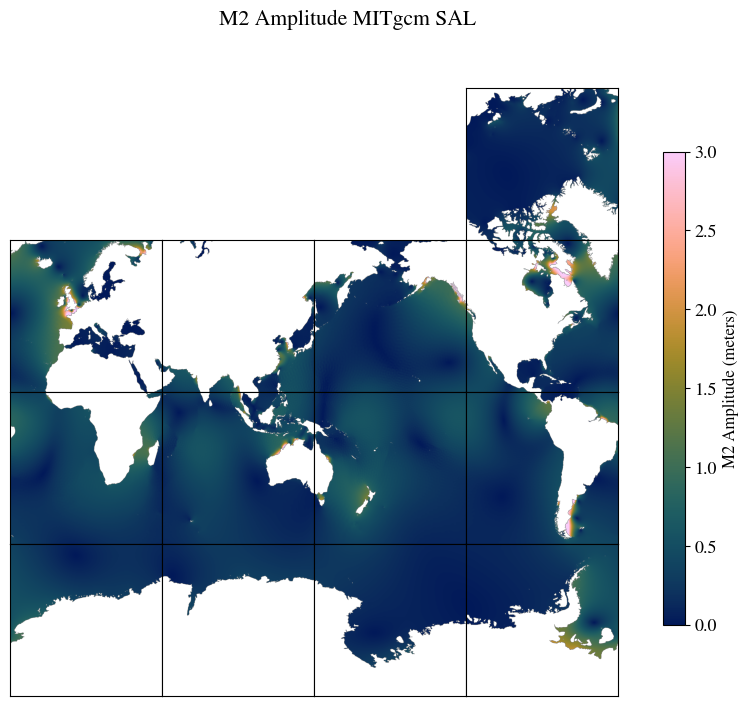

In [84]:
ecco.plot_tiles(amp_mitgcm_SAL, cmap=cm.batlow, show_colorbar=True,cmin = 0, cmax =3, rotate_to_latlon=True,layout='latlon',
                show_tile_labels=False, Arctic_cap_tile_location=10)
plt.suptitle('M2 Amplitude MITgcm SAL')
cb = plt.gcf().axes[-1]
cb.set_ylabel('M2 Amplitude (meters)', fontsize=12)

/Users/hugopp/ECCOv4-py/ECCOv4-py/ecco_v4_py/tile_plot.py:207: UserWarning: Will not return array for non llc90 data
  warnings.warn('Will not return array for non llc90 data')


Text(0, 0.5, 'M2 Amplitude (meters)')

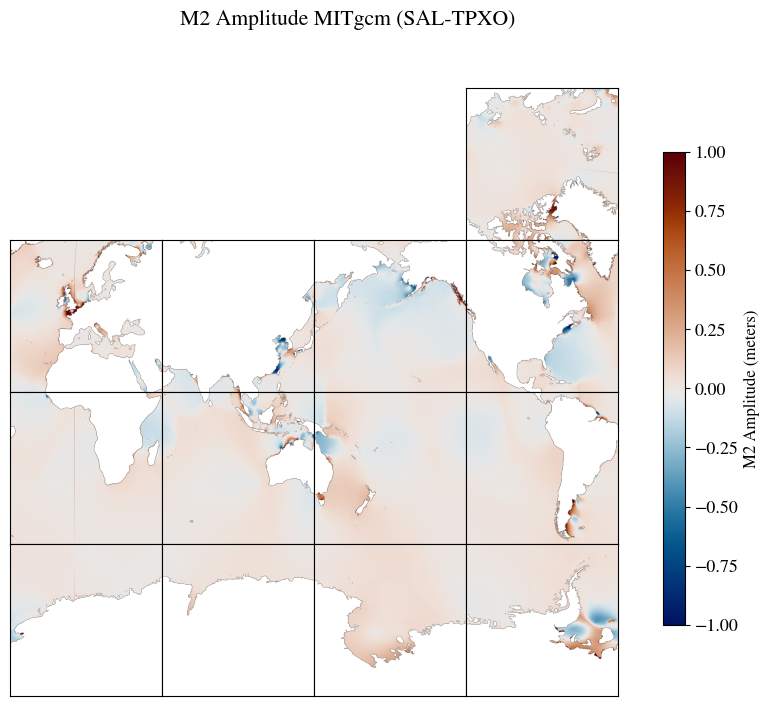

In [85]:
ecco.plot_tiles(amp_mitgcm_SAL-amp_tpxo, cmap=cm.vik, show_colorbar=True, cmin=-1,cmax=1, rotate_to_latlon=True,layout='latlon',
                show_tile_labels=False, Arctic_cap_tile_location=10)
plt.suptitle('M2 Amplitude MITgcm (SAL-TPXO)')
cb = plt.gcf().axes[-1] 
cb.set_ylabel('M2 Amplitude (meters)', fontsize=12)
#plt.savefig('../Plots/fixed_time/M2_amp_MITgcm_SAL-TPXO.pdf',bbox_inches='tight',dpi=300)

/Users/hugopp/ECCOv4-py/ECCOv4-py/ecco_v4_py/tile_plot.py:207: UserWarning: Will not return array for non llc90 data
  warnings.warn('Will not return array for non llc90 data')


Text(0, 0.5, 'M2 Amplitude (meters)')

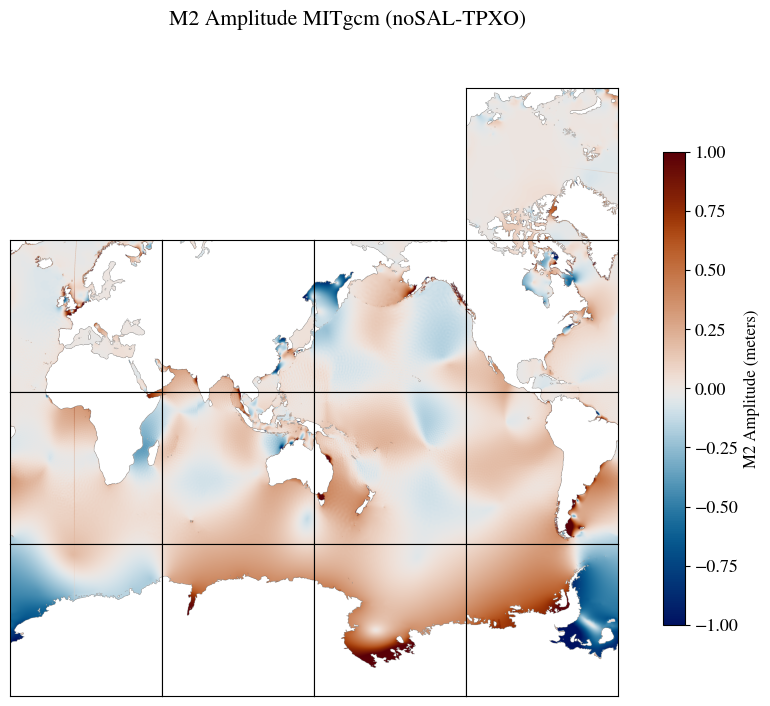

In [86]:
ecco.plot_tiles(amp_mitgcm_noSAL-amp_tpxo, cmap=cm.vik, show_colorbar=True, cmin=-1,cmax=1, rotate_to_latlon=True,layout='latlon',
                show_tile_labels=False, Arctic_cap_tile_location=10)
plt.suptitle('M2 Amplitude MITgcm (noSAL-TPXO)')
cb = plt.gcf().axes[-1] 
cb.set_ylabel('M2 Amplitude (meters)', fontsize=12)
#plt.savefig('../Plots/fixed_time/M2_amp_MITgcm_noSAL-TPXO.pdf',bbox_inches='tight',dpi=300)

/Users/hugopp/ECCOv4-py/ECCOv4-py/ecco_v4_py/tile_plot.py:207: UserWarning: Will not return array for non llc90 data
  warnings.warn('Will not return array for non llc90 data')


Text(0, 0.5, 'M2 Amplitude (meters)')

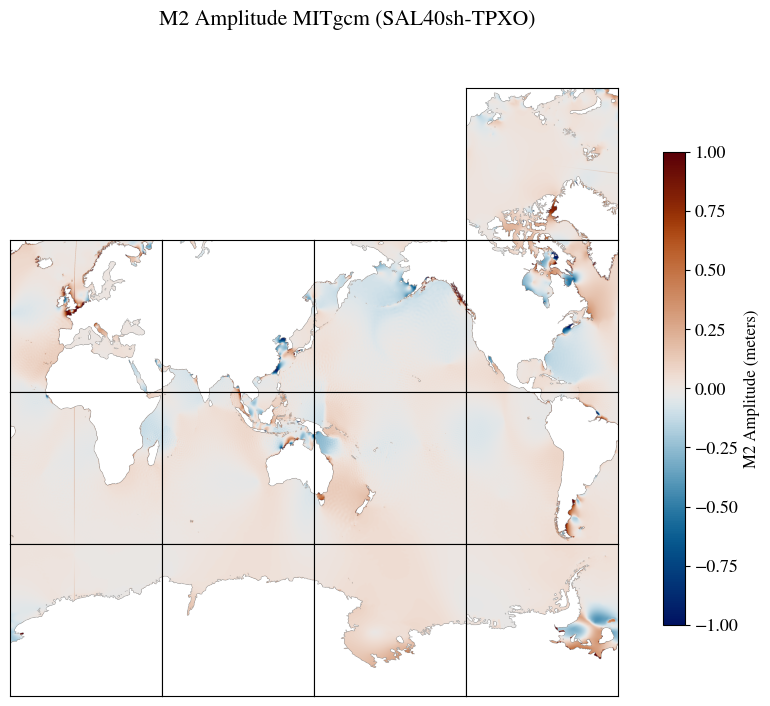

In [87]:
ecco.plot_tiles(amp_mitgcm_SAL40sh-amp_tpxo, cmap=cm.vik, show_colorbar=True, cmin=-1,cmax=1, rotate_to_latlon=True,layout='latlon',
                show_tile_labels=False, Arctic_cap_tile_location=10)
plt.suptitle('M2 Amplitude MITgcm (SAL40sh-TPXO)')
cb = plt.gcf().axes[-1] 
cb.set_ylabel('M2 Amplitude (meters)', fontsize=12)
#plt.savefig('../Plots/fixed_time/M2_amp_MITgcm_SAL40sh-TPXO.pdf',bbox_inches='tight',dpi=300)

/Users/hugopp/ECCOv4-py/ECCOv4-py/ecco_v4_py/tile_plot.py:207: UserWarning: Will not return array for non llc90 data
  warnings.warn('Will not return array for non llc90 data')


Text(0, 0.5, 'M2 Phase (°)')

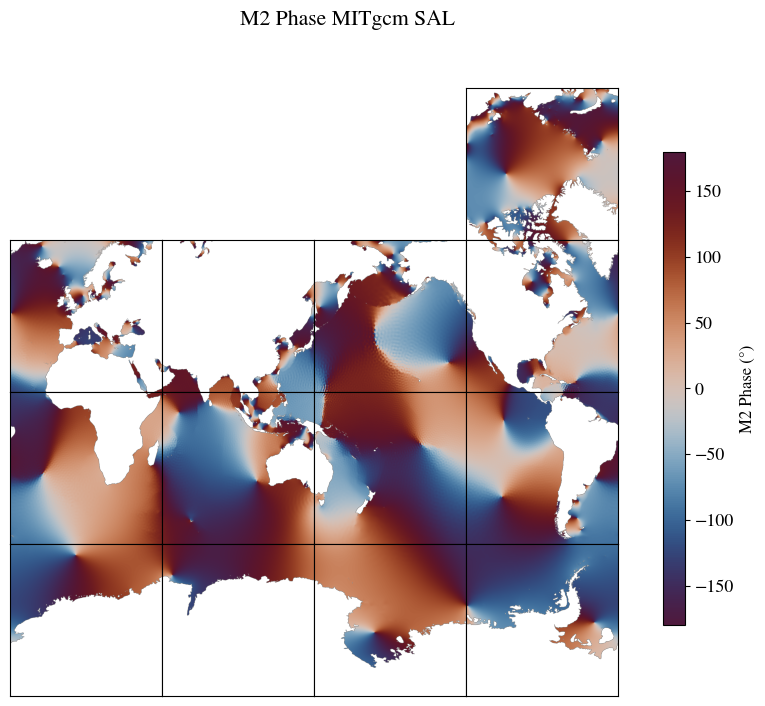

In [88]:
phase_mitgcm_SAL_deg = phase_rad2deg(phase_mitgcm_SAL,Z_mitgcm_SAL)

ecco.plot_tiles(phase_mitgcm_SAL_deg, cmap=cm.vikO, show_colorbar=True, rotate_to_latlon=True,layout='latlon',
                show_tile_labels=False, Arctic_cap_tile_location=10)
plt.suptitle('M2 Phase MITgcm SAL')
cb = plt.gcf().axes[-1] 
cb.set_ylabel('M2 Phase (°)', fontsize=12)

Text(0, 0.5, 'M2 Phase (°)')

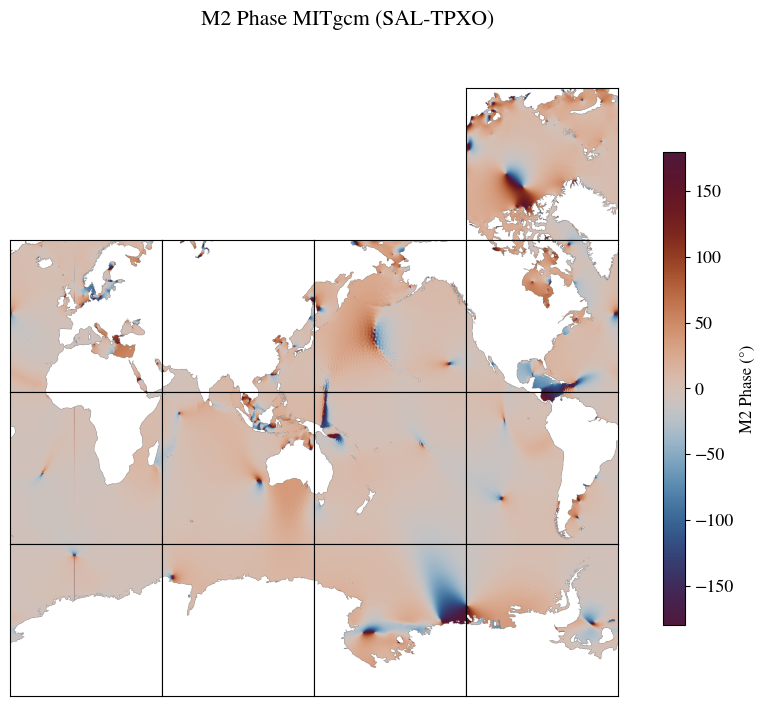

In [89]:
phase_diff_SAL_tpxo_deg = phase_rad2deg(phase_diff_SAL_tpxo, Z_mitgcm_SAL)

ecco.plot_tiles(phase_diff_SAL_tpxo_deg, cmap=cm.vikO, show_colorbar=True, rotate_to_latlon=True,layout='latlon',
                show_tile_labels=False, Arctic_cap_tile_location=10)
plt.suptitle('M2 Phase MITgcm (SAL-TPXO)')
cb = plt.gcf().axes[-1] # The colorbar is usually the last axis added to the figure
cb.set_ylabel('M2 Phase (°)', fontsize=12)
#plt.savefig('../Plots/fixed_time/M2_phase_MITgcm_SAL-TPXO.pdf',bbox_inches='tight',dpi=300)

Text(0, 0.5, 'M2 Phase (°)')

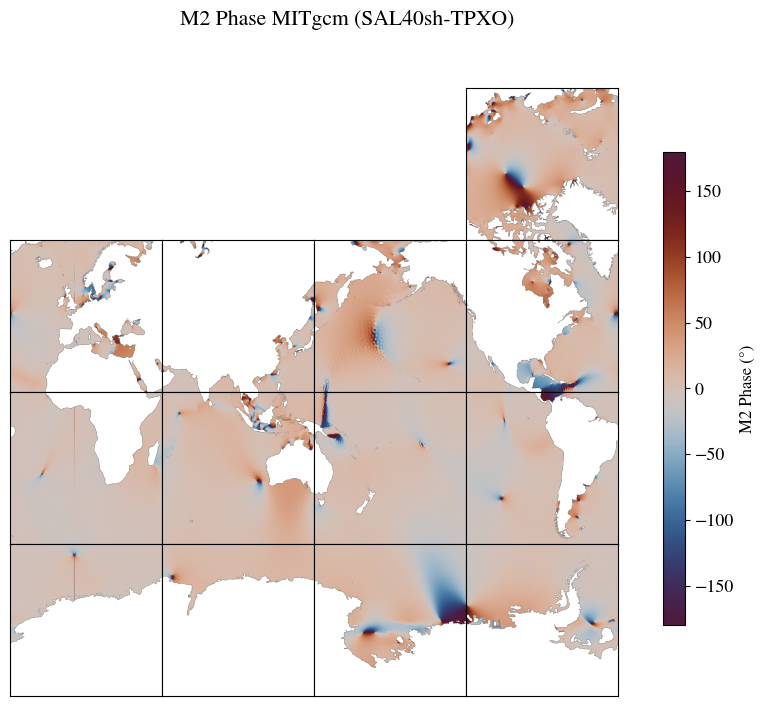

In [90]:
phase_diff_SAL40sh_tpxo_deg = phase_rad2deg(phase_diff_SAL40sh_tpxo, Z_mitgcm_SAL)

ecco.plot_tiles(phase_diff_SAL_tpxo_deg, cmap=cm.vikO, show_colorbar=True, rotate_to_latlon=True,layout='latlon',
                show_tile_labels=False, Arctic_cap_tile_location=10)
plt.suptitle('M2 Phase MITgcm (SAL40sh-TPXO)')
cb = plt.gcf().axes[-1] # The colorbar is usually the last axis added to the figure
cb.set_ylabel('M2 Phase (°)', fontsize=12)
#plt.savefig('../Plots/fixed_time/M2_phase_MITgcm_SAL40sh-TPXO.pdf',bbox_inches='tight',dpi=300)

Text(0, 0.5, 'M2 Phase (°)')

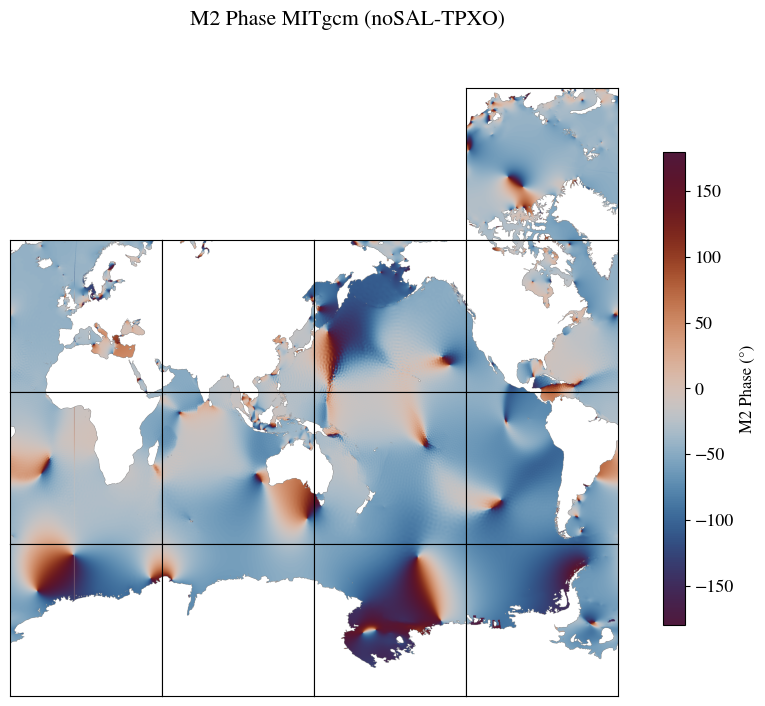

In [91]:
phase_diff_noSAL_tpxo_deg = phase_rad2deg(phase_diff_noSAL_tpxo, Z_mitgcm_noSAL)

ecco.plot_tiles(phase_diff_noSAL_tpxo_deg, cmap=cm.vikO, show_colorbar=True, rotate_to_latlon=True,layout='latlon',
                show_tile_labels=False, Arctic_cap_tile_location=10)
plt.suptitle('M2 Phase MITgcm (noSAL-TPXO)')
cb = plt.gcf().axes[-1] # The colorbar is usually the last axis added to the figure
cb.set_ylabel('M2 Phase (°)', fontsize=12)
#plt.savefig('../Plots/fixed_time/M2_phase_MITgcm_noSAL-TPXO.pdf',bbox_inches='tight',dpi=300)

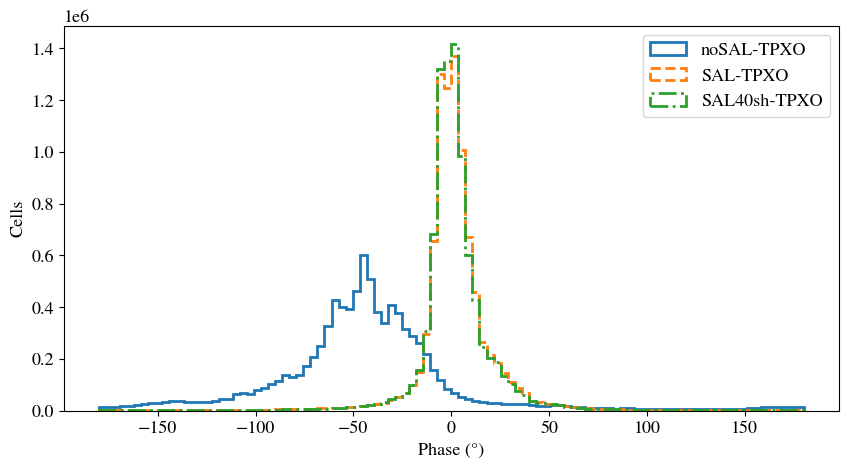

In [92]:
plt.figure(figsize=(10,5))
plt.hist(phase_diff_noSAL_tpxo_deg.values.flatten(), bins=100, histtype='step',label='noSAL-TPXO',lw=2,color='C0')
plt.hist(phase_diff_SAL_tpxo_deg.values.flatten(), bins=100, histtype='step',label='SAL-TPXO',lw=2,ls='--',color='C1')
plt.hist(phase_diff_SAL40sh_tpxo_deg.values.flatten(), bins=100, histtype='step',label='SAL40sh-TPXO',ls='-.',lw=2,color='C2')
plt.xlabel('Phase (°)')
plt.ylabel('Cells')
plt.legend()
#plt.savefig('../Plots/fixed_time/histogram.pdf',bbox_inches='tight',dpi=300)

### Tidal workrate plots

/Users/hugopp/ECCOv4-py/ECCOv4-py/ecco_v4_py/tile_plot.py:207: UserWarning: Will not return array for non llc90 data
  warnings.warn('Will not return array for non llc90 data')


Text(0, 0.5, 'M2 Workrate [mW/m$^2$]')

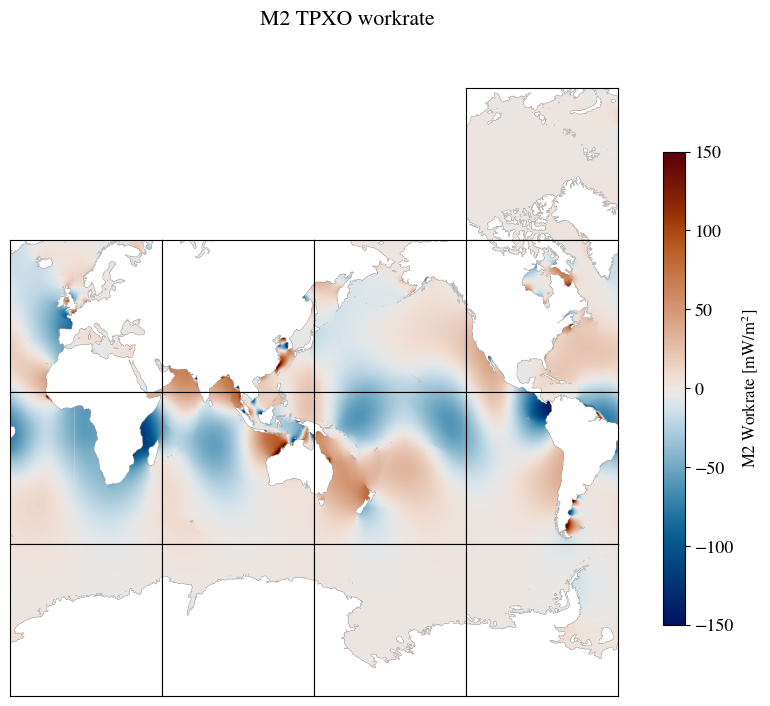

In [113]:
ecco.plot_tiles(Pmap_tpxo, cmap=cm.vik, show_colorbar=True,rotate_to_latlon=True,layout='latlon',
                cmin=-150, cmax = 150,
                show_tile_labels=False, Arctic_cap_tile_location=10)
plt.suptitle('M2 TPXO workrate')
cb = plt.gcf().axes[-1]
cb.set_ylabel(r'M2 Workrate [mW/m$^2$]', fontsize=12)

/Users/hugopp/ECCOv4-py/ECCOv4-py/ecco_v4_py/tile_plot.py:207: UserWarning: Will not return array for non llc90 data
  warnings.warn('Will not return array for non llc90 data')


Text(0, 0.5, 'M2 Workrate [mW/m$^2$]')

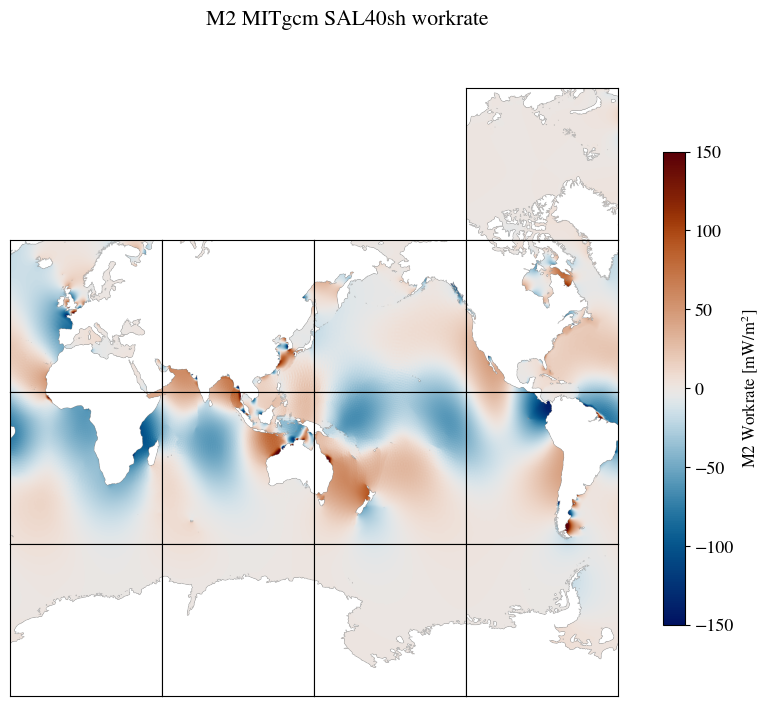

In [114]:
ecco.plot_tiles(Pmap_mitgcm_SAL40sh, cmap=cm.vik, show_colorbar=True,rotate_to_latlon=True,layout='latlon',
                cmin=-150, cmax = 150,
                show_tile_labels=False, Arctic_cap_tile_location=10)
plt.suptitle('M2 MITgcm SAL40sh workrate')
cb = plt.gcf().axes[-1]
cb.set_ylabel(r'M2 Workrate [mW/m$^2$]', fontsize=12)

/Users/hugopp/ECCOv4-py/ECCOv4-py/ecco_v4_py/tile_plot.py:207: UserWarning: Will not return array for non llc90 data
  warnings.warn('Will not return array for non llc90 data')


Text(0, 0.5, 'M2 Workrate Difference [mW/m$^2$]')

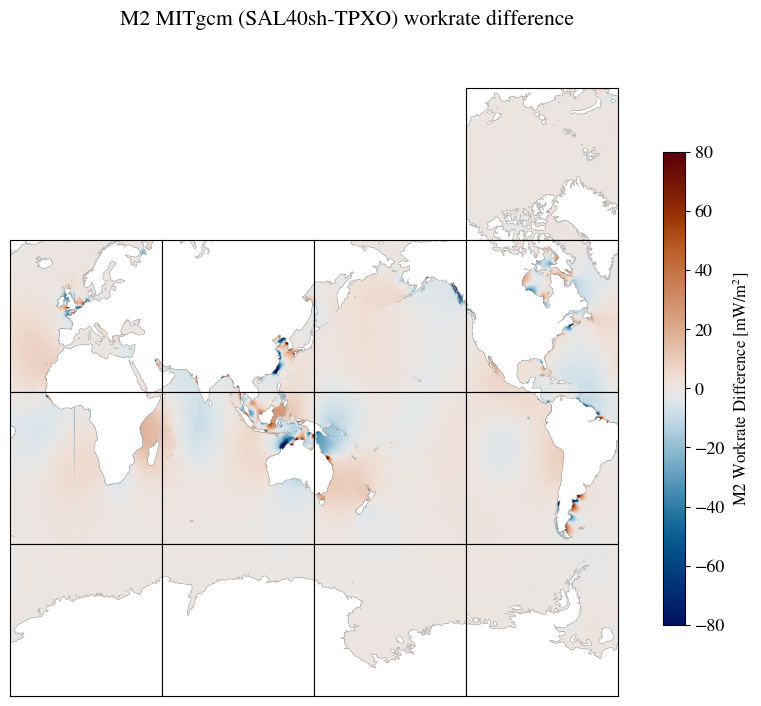

In [118]:
ecco.plot_tiles(Pmap_mitgcm_SAL40sh-Pmap_tpxo, cmap=cm.vik, show_colorbar=True,rotate_to_latlon=True,layout='latlon',
                cmin=-80, cmax = 80,
                show_tile_labels=False, Arctic_cap_tile_location=10)
plt.suptitle('M2 MITgcm (SAL40sh-TPXO) workrate difference')
cb = plt.gcf().axes[-1]
cb.set_ylabel(r'M2 Workrate Difference [mW/m$^2$]', fontsize=12)